# Day 6: Data Visualization using Python

## Objective
Learn the importance of data visualization and create meaningful charts using Matplotlib and Seaborn.

## Dataset
This notebook uses the student performance dataset from Day 5, containing student details, department, attendance, Python marks, Machine Learning marks, and number of projects completed.

## Libraries Used
- **Pandas:** Data loading and analysis
- **Matplotlib:** Creating charts and customizing plots
- **Seaborn:** Statistical data visualization

## Learning Overview

Data visualization helps communicate patterns, comparisons, distributions, and relationships through charts. Matplotlib provides detailed control over chart elements, while Seaborn simplifies statistical visualization and integrates with Pandas.


## 1. Import Libraries and Load Dataset

Import the required libraries and load the student dataset into a Pandas DataFrame. Inspect the dataset to understand its structure and identify missing values.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_data.csv")

sns.set_theme(style="whitegrid")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (20, 8)


,Student_ID,Name,Department,Age,Attendance,Python_Marks,ML_Marks,Projects
0,101,Aarav,CSE,20.0,92.0,85.0,88.0,3.0
1,102,Diya,AIML,21.0,87.0,78.0,91.0,2.0
2,103,Rohan,CSE,NaN,76.0,69.0,74.0,1.0
3,104,Meera,AIML,20.0,NaN,92.0,89.0,4.0
4,105,Kabir,CSE,22.0,81.0,NaN,72.0,2.0


## 2. Explore Missing Values

Check the dataset for missing entries in each column. Missing values are excluded from the relevant calculations and visualizations where appropriate; they are not automatically treated as zero.

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Missing values in each column:
Student_ID      0
Name            0
Department      0
Age             3
Attendance      3
Python_Marks    3
ML_Marks        2
Projects        1
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_ID    20 non-null     int64  
 1   Name          20 non-null     str    
 2   Department    20 non-null     str    
 3   Age           17 non-null     float64
 4   Attendance    17 non-null     float64
 5   Python_Marks  17 non-null     float64
 6   ML_Marks      18 non-null     float64
 7   Projects      19 non-null     float64
dtypes: float64(5), int64(1), str(2)
memory usage: 1.4 KB


## 3. Bar Chart: Average Subject Marks by Department

**Objective:** Compare the average Python and Machine Learning marks of CSE and AIML students.

**Concept Learned:** Bar charts are useful for comparing numerical values across categories. Using Pandas `groupby()` and `mean()` allows us to calculate department-wise averages before plotting them.

**Interpretation:** Compare the heights of the bars to identify differences in average subject performance between departments.


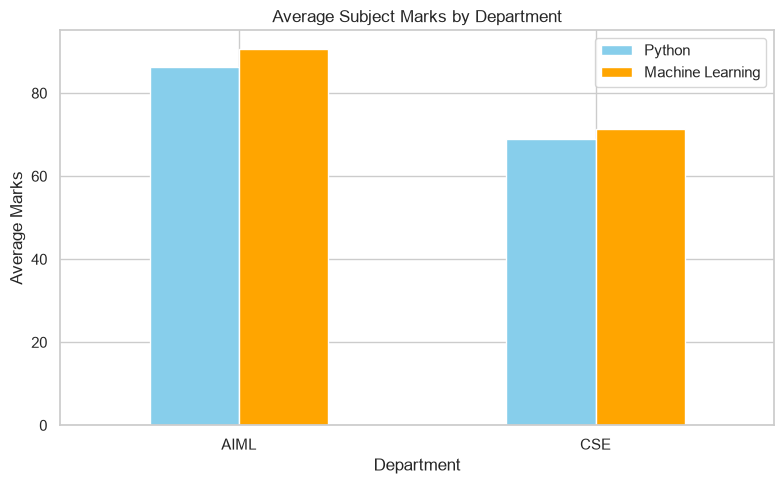

In [5]:
avg_marks = df.groupby("Department")[
    ["Python_Marks", "ML_Marks"]
].mean()

avg_marks.plot(
    kind="bar",
    figsize=(8, 5),
    color=["skyblue", "orange"]
)

plt.title("Average Subject Marks by Department")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.legend(["Python", "Machine Learning"])
plt.tight_layout()
plt.show()

## 4. Line Chart: Python vs Machine Learning Marks

**Objective:** Compare Python and Machine Learning marks for individual students using their Student IDs on the x-axis.

**Concept Learned:** The `plt.plot()` function creates line charts. The `marker` parameter highlights individual data points, while `label` identifies each data series in the legend. Axis labels and titles make the chart easier to understand.

**Interpretation:** Compare the two lines to identify students whose Python marks are higher than their ML marks and vice versa. Missing marks appear as gaps in the lines. Since Student IDs are identifiers rather than a time sequence, the connected lines are used for comparison, not to establish a trend over time.


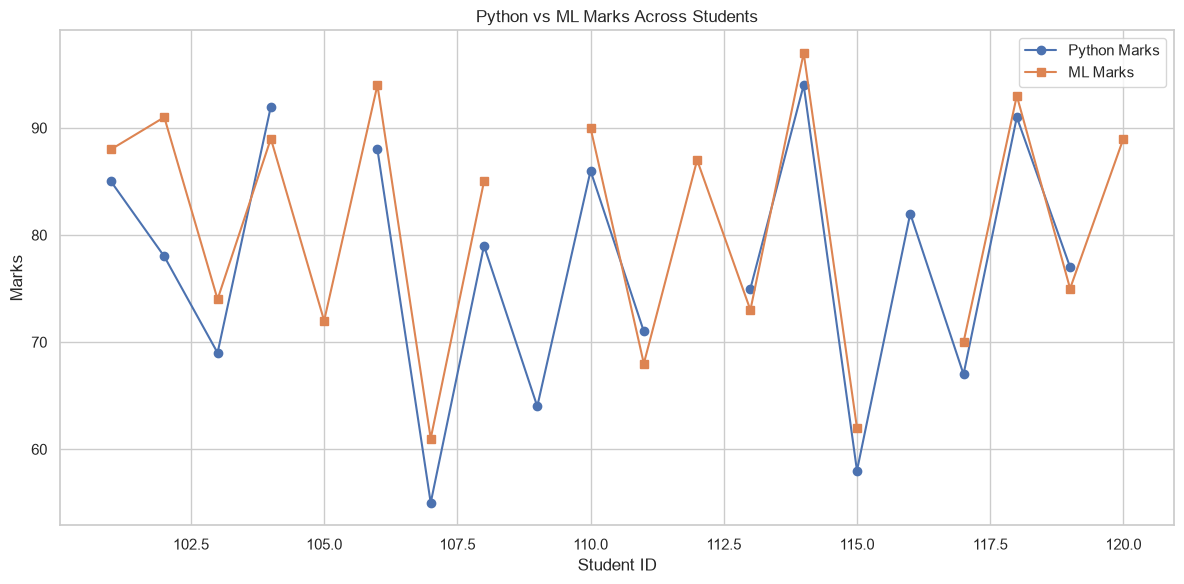

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Student_ID"],
    df["Python_Marks"],
    marker="o",
    label="Python Marks"
)

plt.plot(
    df["Student_ID"],
    df["ML_Marks"],
    marker="s",
    label="ML Marks"
)

plt.title("Python vs ML Marks Across Students")
plt.xlabel("Student ID")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Histogram: Distribution of Student Attendance

**Objective:** Visualize how student attendance values are distributed across different ranges.

**Concept Learned:** A histogram represents the frequency distribution of numerical data. The `sns.histplot()` function creates the histogram, while the `bins` parameter determines how the attendance range is divided into intervals. The height of each bar indicates the number of recorded observations within that interval.

**Interpretation:** Observe which attendance ranges contain the most students and whether the recorded attendance values are concentrated in a particular range or spread across several ranges. Missing attendance values are excluded from the histogram.


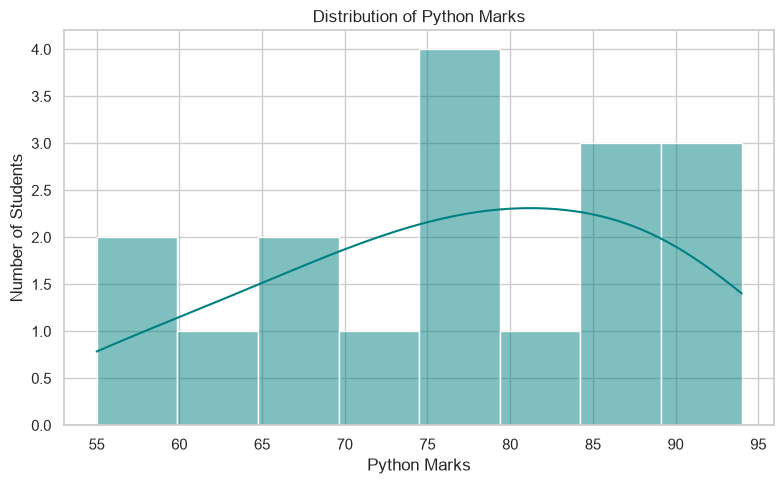

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Python_Marks",
    bins=8,
    kde=True,
    color="teal"
)

plt.title("Distribution of Python Marks")
plt.xlabel("Python Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

## 6. Pie Chart: Distribution of Students by Projects Completed

**Objective:** Represent the distribution of students according to the number of projects they have completed.

**Concept Learned:** Pie charts display categories as proportions of a whole. The Pandas `value_counts()` function counts students in each project-count category, while `sort_index()` arranges the categories in ascending order. In Matplotlib, `labels` identifies each slice and `autopct` displays its percentage.

**Interpretation:** Compare the sizes of the slices to identify the most common project-count category and understand how students are distributed across the different categories. The student with a missing project count is excluded, so the percentages represent only students with recorded project data.


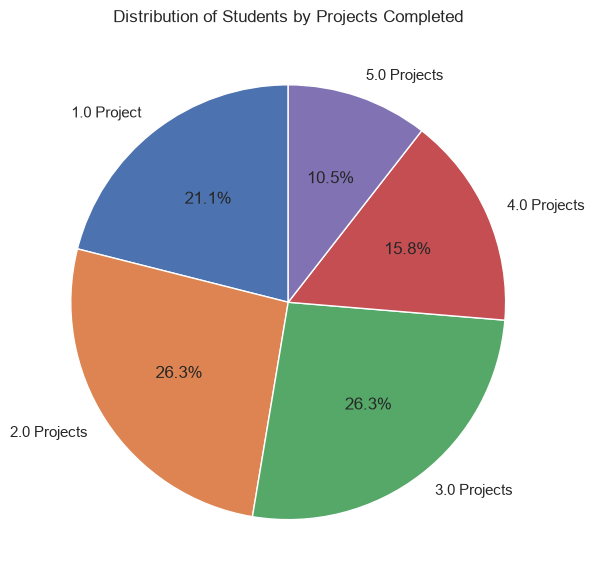

In [8]:
project_counts = df["Projects"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

plt.pie(
    project_counts.values,
    labels=[
        f"{projects} Project{'s' if projects != 1 else ''}"
        for projects in project_counts.index
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Students by Projects Completed")
plt.tight_layout()
plt.show()

## 7. Scatter Plot: Relationship Between Python and ML Marks

**Objective:** Explore the relationship between students' Python marks and Machine Learning marks, while distinguishing students by department.

**Concept Learned:** A scatter plot displays the relationship between two numerical variables using individual data points. The `sns.scatterplot()` function creates the plot, while `x` and `y` specify the variables to compare. The `hue` parameter uses different colours to distinguish departments, and `s` controls the marker size.

**Interpretation:** Observe whether students with higher Python marks also tend to have higher ML marks. The colours help compare the two departments. Students with missing marks in either subject are excluded from the plot.


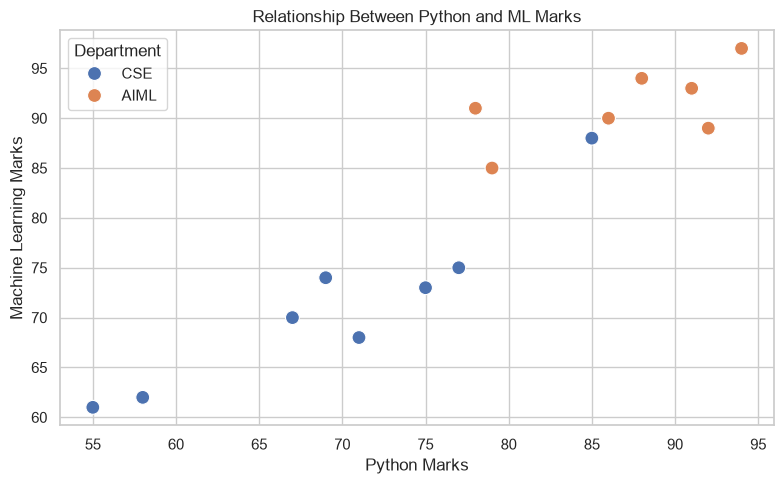

In [9]:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Python_Marks",
    y="ML_Marks",
    hue="Department",
    s=100
)

plt.title("Relationship Between Python and ML Marks")
plt.xlabel("Python Marks")
plt.ylabel("Machine Learning Marks")
plt.tight_layout()
plt.show()

## 8. Key Observations

Analyze the generated charts and record five observations supported by the dataset. Consider differences in subject averages between departments, the relationship between Python and ML marks for individual students, the distribution of attendance, and the most common project-count category.

The observations should be based on the actual chart results rather than assumptions.

In [10]:
python_avg = df["Python_Marks"].mean()
ml_avg = df["ML_Marks"].mean()

dept_python = df.groupby("Department")["Python_Marks"].mean()
dept_counts = df["Department"].value_counts()

highest_python = df.loc[df["Python_Marks"].idxmax()]
highest_ml = df.loc[df["ML_Marks"].idxmax()]

print("OBSERVATION SUMMARY")
print("-" * 40)

print(
    f"1. The dataset contains {len(df)} students, "
    f"with {dept_counts.get('CSE', 0)} CSE students "
    f"and {dept_counts.get('AIML', 0)} AIML students."
)

print(
    f"2. The overall average Python mark is "
    f"{python_avg:.2f}, while the overall average ML mark is "
    f"{ml_avg:.2f}."
)

print(
    f"3. {dept_python.idxmax()} has the higher average Python mark "
    f"({dept_python.max():.2f}) compared with "
    f"{dept_python.idxmin()} ({dept_python.min():.2f})."
)

print(
    f"4. The highest recorded Python mark is "
    f"{highest_python['Python_Marks']:.0f}, achieved by "
    f"{highest_python['Name']}."
)

print(
    f"5. The highest recorded ML mark is "
    f"{highest_ml['ML_Marks']:.0f}, achieved by "
    f"{highest_ml['Name']}."
)

OBSERVATION SUMMARY
----------------------------------------
1. The dataset contains 20 students, with 10 CSE students and 10 AIML students.
2. The overall average Python mark is 77.12, while the overall average ML mark is 81.00.
3. AIML has the higher average Python mark (86.25) compared with CSE (69.00).
4. The highest recorded Python mark is 94, achieved by Kiara.
5. The highest recorded ML mark is 97, achieved by Kiara.


## 9. Conclusion and Key Learnings

This task provided practical experience in creating bar charts, line charts, histograms, and pie charts using Matplotlib and Seaborn.

I learned how to compare numerical values across categories, visualize individual observations, examine numerical distributions, and represent categorical proportions. I also learned the importance of chart selection, labels, legends, and handling missing values appropriately.

These techniques help convert raw datasets into visual information that is easier to interpret and communicate.
